In [1]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np

In [2]:
# Keep only 'datetime' and 'sensor.power_load_no_var_loads', replace NA with 0
df = pd.read_csv('long_train_data.csv')
df = df[['datetime', 'sensor.power_load_no_var_loads']].copy()
df = df.fillna(0)
df.head()

,datetime,sensor.power_load_no_var_loads
0,2024-02-28 21:00:00+00:00,0.0
1,2024-02-28 21:30:00+00:00,0.0
2,2024-02-28 22:00:00+00:00,0.0
3,2024-02-28 22:30:00+00:00,0.0
4,2024-02-28 23:00:00+00:00,0.0


<Axes: >

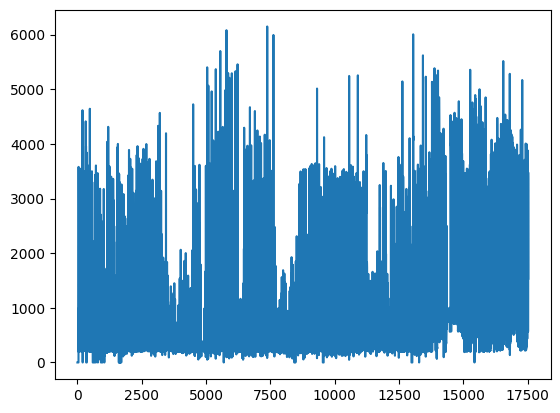

In [3]:
load = df['sensor.power_load_no_var_loads']
load.plot()

In [4]:
import plotly.graph_objs as go
import plotly.offline as pyo

df['datetime'] = pd.to_datetime(df['datetime'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['datetime'], y=df['sensor.power_load_no_var_loads'], mode='lines', name='Load'))
fig.update_layout(title='Interactive Energy Consumption', xaxis_title='Datetime', yaxis_title='Load')
fig.show()

In [5]:
# Normalize the input data
load_mean = np.mean(load)
load_std = np.std(load)
load_normalized = (load - load_mean) / load_std

# Add datetime features
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = (df['datetime'].dt.dayofweek >= 5).astype(int)

# Encode cyclical features
df['hour_sin'] = np.sin(df['hour'] * (2 * np.pi / 24))
df['hour_cos'] = np.cos(df['hour'] * (2 * np.pi / 24))
df['day_sin'] = np.sin(df['day_of_week'] * (2 * np.pi / 7))
df['day_cos'] = np.cos(df['day_of_week'] * (2 * np.pi / 7))

In [6]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [7]:
def create_time_features_dataset(df, target_col, window_size=48):
    """Create a windowed dataset with time features included"""
    X = []
    y = []
    
    # List of feature columns (excluding target and datetime)
    feature_cols = [col for col in df.columns if col not in [target_col, 'datetime']]
    
    for i in range(len(df) - window_size):
        # Get window of target variable
        target_window = df[target_col].iloc[i:i+window_size].values.reshape(-1, 1)
        
        # Get corresponding window of time features
        features_window = df[feature_cols].iloc[i:i+window_size].values
        
        # Combine into one window array with shape (window_size, features+1)
        combined = np.concatenate([target_window, features_window], axis=1)
        
        X.append(combined)
        y.append(df[target_col].iloc[i+window_size])
        
    return np.array(X), np.array(y)

In [8]:
# Use time features and a larger window
WINDOW_SIZE = 48
X, y = create_time_features_dataset(df, 'sensor.power_load_no_var_loads', window_size=WINDOW_SIZE)

# Normalize all features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_shape = X.shape
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped).reshape(X_shape)

# Split
n = X_scaled.shape[0]
train_end = int(n * 0.7)
val_end = int(n * 0.85)
X_train, y_train = X_scaled[:train_end], y[:train_end]
X_val, y_val = X_scaled[train_end:val_end], y[train_end:val_end]
X_test, y_test = X_scaled[val_end:], y[val_end:]

# Improved model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, LSTM, Bidirectional, Dropout, BatchNormalization, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model = Sequential([
    InputLayer((WINDOW_SIZE, X_train.shape[2])),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32),
    Dropout(0.2),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.001),
    metrics=[RootMeanSquaredError()]
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
checkpoint = ModelCheckpoint('improved_lstm.keras', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 1014513.3125 - root_mean_squared_error: 1006.8214 - val_loss: 2111578.2500 - val_root_mean_squared_error: 1453.1271 - learning_rate: 0.0010
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 577511.0625 - root_mean_squared_error: 758.9326 - val_loss: 893098.2500 - val_root_mean_squared_error: 945.0388 - learning_rate: 0.0010
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 360363.4688 - root_mean_squared_error: 599.6222 - val_loss: 728083.3125 - val_root_mean_squared_error: 853.2780 - learning_rate: 0.0010
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 314143.4062 - root_mean_squared_error: 560.0975 - val_loss: 687610.5000 - val_root_mean_squared_error: 829.2228 - learning_rate: 0.0010
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 286212.4062 - root_mean_squared_error: 534.7957 - val_loss: 691887.6250 - val_root_mean_squared_error: 831.7979 - learning_rate: 0.0010
Epoch 

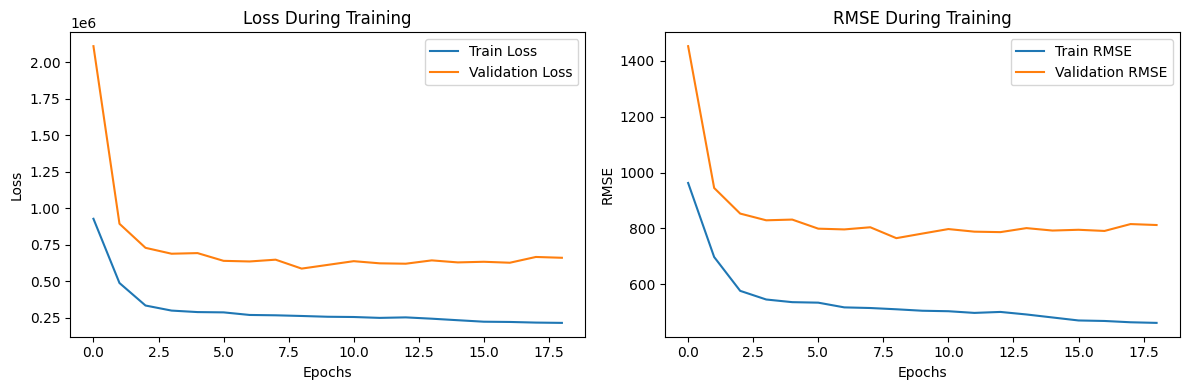

383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Train RMSE: 467.4649, MAE: 258.4576, R²: 0.6475
Val   RMSE: 765.2204, MAE: 496.4149, R²: 0.5167
Test  RMSE: 729.9530, MAE: 508.7900, R²: 0.5966


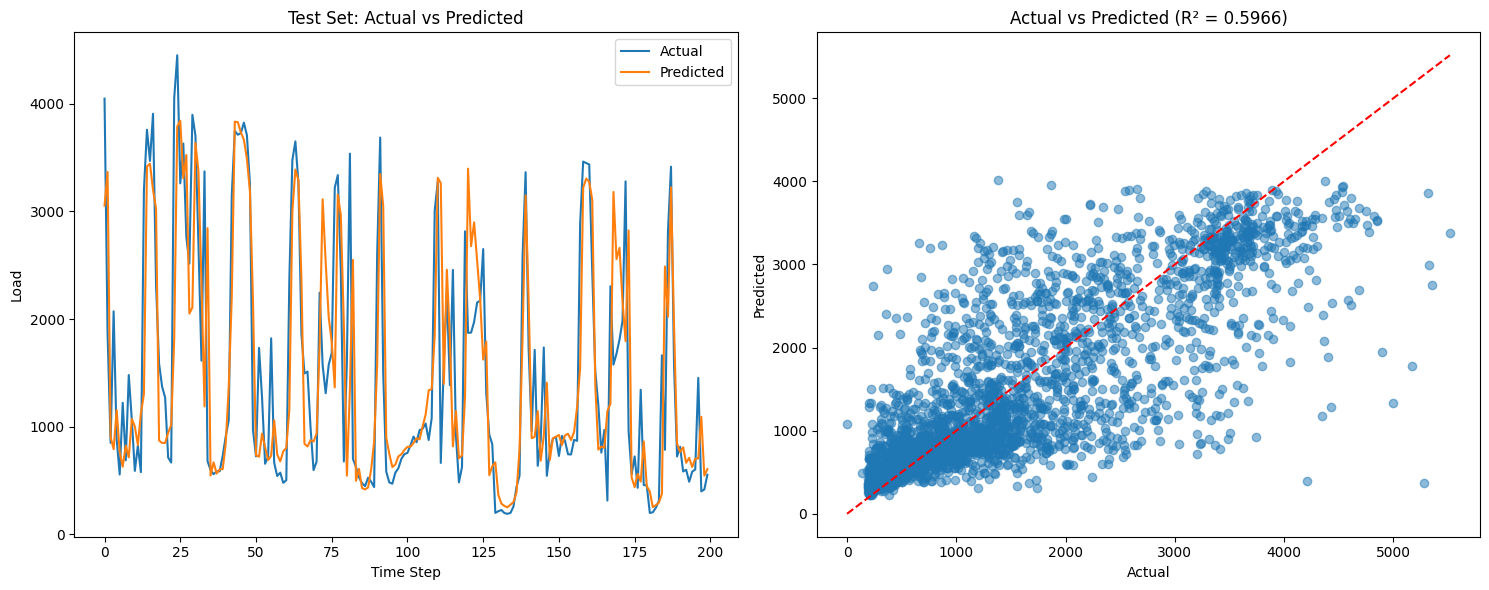

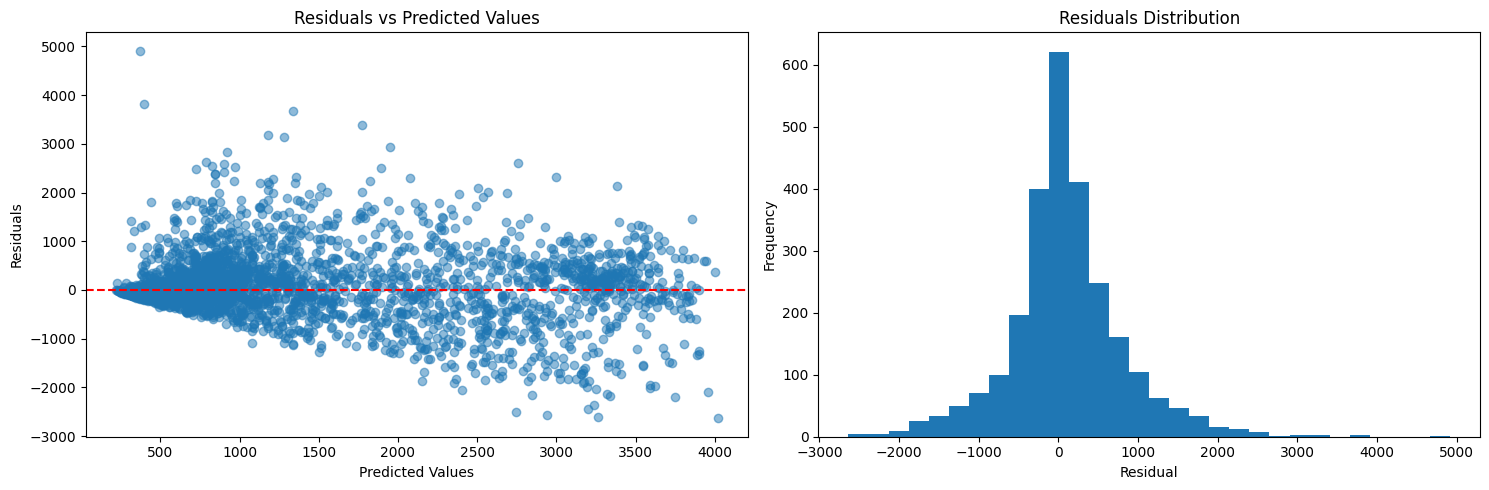

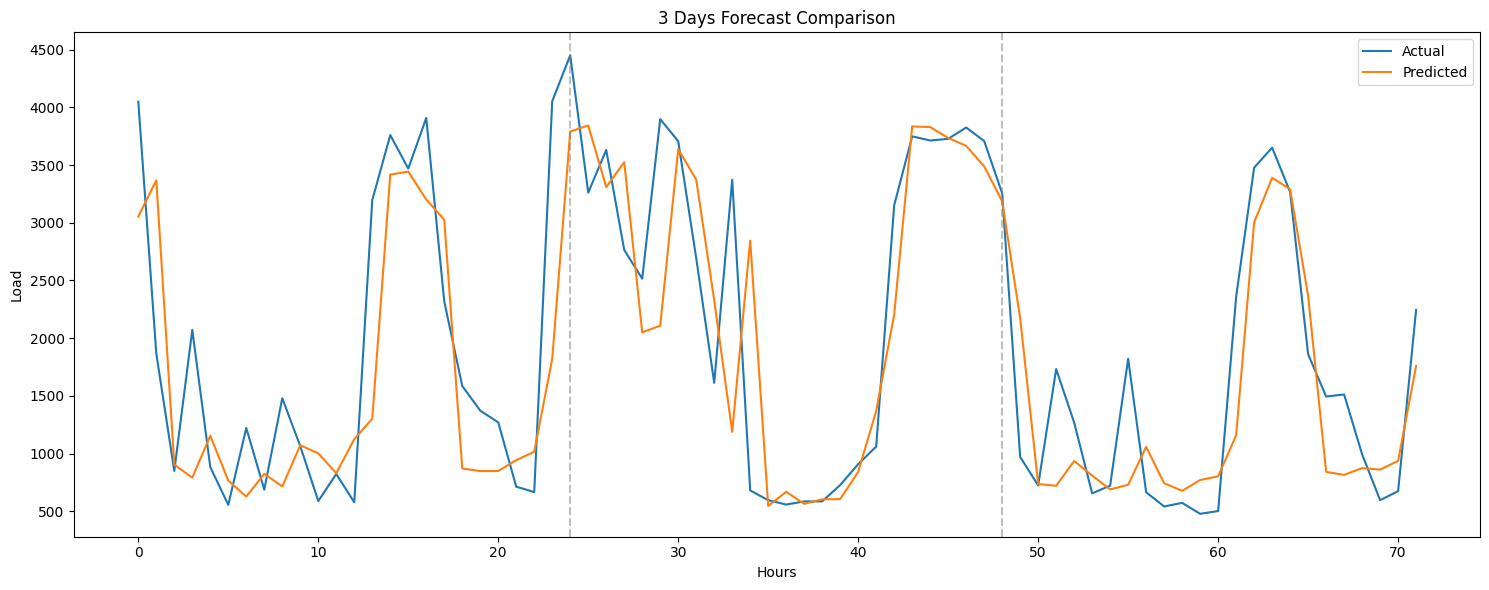

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
plt.title('RMSE During Training')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Make predictions on all datasets
train_predictions = model.predict(X_train).flatten()
val_predictions = model.predict(X_val).flatten()
test_predictions = model.predict(X_test).flatten()

# 3. Calculate metrics for each dataset
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

train_rmse, train_mae, train_r2 = calculate_metrics(y_train, train_predictions)
val_rmse, val_mae, val_r2 = calculate_metrics(y_val, val_predictions)
test_rmse, test_mae, test_r2 = calculate_metrics(y_test, test_predictions)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Val   RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

# 4. Visualize predictions vs actual values for test set
# Convert from standardized values back to original scale if needed
# If you have the original mean and std, you can use:
# y_test_original = y_test * load_std + load_mean
# test_predictions_original = test_predictions * load_std + load_mean

plt.figure(figsize=(15, 6))
# Plot a sample of points (e.g., 200 points)
sample_size = min(200, len(y_test))
plt.subplot(1, 2, 1)
plt.plot(y_test[:sample_size], label='Actual')
plt.plot(test_predictions[:sample_size], label='Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Time Step')
plt.ylabel('Load')
plt.legend()

# 5. Create a scatter plot to visualize the correlation
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Actual vs Predicted (R² = {test_r2:.4f})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

# 6. Visualize residuals
residuals = y_test - test_predictions
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(test_predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 7. Compare consecutive 24-hour forecasts 
days_to_show = 3
samples_per_day = 24  # Assuming hourly data
total_samples = days_to_show * samples_per_day
if len(y_test) >= total_samples:
    plt.figure(figsize=(15, 6))
    plt.plot(y_test[:total_samples], label='Actual')
    plt.plot(test_predictions[:total_samples], label='Predicted')
    
    # Add vertical lines to separate days
    for day in range(1, days_to_show):
        plt.axvline(x=day*samples_per_day, color='gray', linestyle='--', alpha=0.5)
    
    plt.title(f'{days_to_show} Days Forecast Comparison')
    plt.xlabel('Hours')
    plt.ylabel('Load')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# Get test data start and end date
test_start_idx = val_end + WINDOW_SIZE  # account for window offset
test_end_idx = len(df) - 1
test_start_date = df['datetime'].iloc[test_start_idx]
test_end_date = df['datetime'].iloc[test_end_idx]
print(f"Test data starts at: {test_start_date}")
print(f"Test data ends at: {test_end_date}")

Test data starts at: 2025-01-04 08:00:00+00:00
Test data ends at: 2025-02-27 22:30:00+00:00


        Actual    Predicted
0  4048.925889  3053.654785
1  1866.244056  3368.121826
2   848.983611   904.379517
3  2071.718883   790.391418
4   882.376667  1154.121704


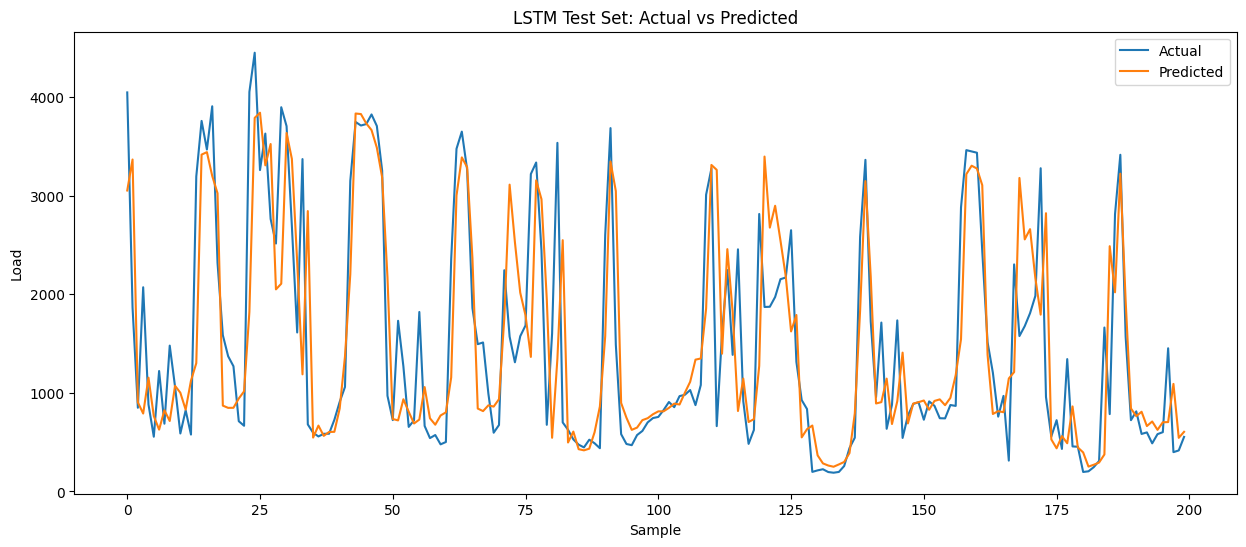

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# If you want to convert back to original scale:
# y_test_original = y_test * load_std + load_mean
# test_predictions_original = test_predictions * load_std + load_mean

# Create DataFrame for test actual and predicted
test_results = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': test_predictions.flatten()
})
print(test_results.head())

# Plot actual vs predicted
plt.figure(figsize=(15, 6))
plt.plot(test_results['Actual'][:200], label='Actual')
plt.plot(test_results['Predicted'][:200], label='Predicted')
plt.xlabel('Sample')
plt.ylabel('Load')
plt.title('LSTM Test Set: Actual vs Predicted')
plt.legend()
plt.show()

In [12]:
cp1 = ModelCheckpoint('improved_model.keras', save_best_only=True)
improved_model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

NameError: name 'improved_model' is not defined